# Import Libs

In [1]:
!pip install opacus
!pip install peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 7.4 MB/s eta 0:00:00


In [2]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.9
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
aiosqlite                                0.21.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.2
altair                                   5.5.0
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                                    4.12.0
anywidget                           

In [2]:
import torch
import time

from collections import OrderedDict, deque


import math
import numpy as np

from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator

from peft import LoraConfig, get_peft_model


import torch


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_EPOCHS = 10
BATCH_SIZE = 1024

# Define MLP

In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim=28*28, hidden=256, n_classes=10) -> None:
        super().__init__()
        self.net = nn.Sequential(OrderedDict([
            ("fc1", nn.Linear(input_dim, hidden)),
            ("relu1", nn.ReLU()),
            ("out", nn.Linear(hidden, n_classes))
        ]))
    def forward(self, x):
        x = x.view(x.shape[0], -1)
        return self.net(x)

# DPSGD from Scratch

In [5]:
def get_per_sample_grads(model, x_batch, y_batch, loss_fn):
    """
    Returns a list of dicts: one dict per sample, mapping param_name -> gradient tensor (same shape as param).
    This implementation is straightforward: loop over samples and call backward per-sample.
    """
    model.zero_grad()
    per_sample_grads = []
    params = [p for p in model.parameters() if p.requires_grad]
    param_names = [f"p{i}" for i, _ in enumerate(params)]

    for i in range(x_batch.size(0)):
        out = model(x_batch[i:i+1])
        loss = loss_fn(out, y_batch[i:i+1])
        # compute gradients for this sample
        model.zero_grad()
        loss.backward()
        grads_i = []
        for p in params:
            if p.grad is None:
                grads_i.append(torch.zeros_like(p))
            else:
                grads_i.append(p.grad.detach().clone())
        per_sample_grads.append(grads_i)
    # per_sample_grads: list length B, each is list of param grads
    return per_sample_grads, params

def flatten_stack_grads(per_sample_grads):
    """
    Convert per-sample grads (list of lists of tensors) -> tensor shape (B, P) where P=sum(param.numel())
    Also return shapes to reconstruct.
    """
    B = len(per_sample_grads)
    param_shapes = [g.shape for g in per_sample_grads[0]]
    flat = []
    for i in range(B):
        flat_i = torch.cat([g.reshape(-1) for g in per_sample_grads[i]])
        flat.append(flat_i)
    flat = torch.stack(flat, dim=0) # (B, P)
    return flat, param_shapes

def unflatten_to_param_grads(flat_grad, params, param_shapes):
    """
    Convert 1D flattened grad -> list of param-shaped tensors in same order as params.
    """
    res = []
    idx = 0
    for shape, p in zip(param_shapes, params):
        n = np.prod(shape)
        chunk = flat_grad[idx:idx+n]
        res.append(chunk.view(shape).to(p.device))
        idx += n
    return res

In [ ]:
# def dp_sgd_step(model, x_batch, y_batch, loss_fn, optimizer, C, sigma, lot_size):
#     """
#     model: nn.Module
#     x_batch,y_batch: tensors (batch)
#     C: clipping norm
#     sigma: noise multiplier (std = sigma * C)
#     lot_size: L (used to normalize the noisy sum). For simple usage set lot_size = batch_size here.
#     """
#     model.train()
#     B = x_batch.size(0)

#     per_sample_grads, params = get_per_sample_grads(model, x_batch, y_batch, loss_fn)

#     flat, param_shapes = flatten_stack_grads(per_sample_grads)  # (B, P)

#     # compute l2 norms per sample
#     sample_norms = torch.norm(flat, dim=1)  # (B,)
#     # compute clipping factors
#     clip_factors = (C / (sample_norms + 1e-12)).clamp(max=1.0)
#     # clipped grads
#     flat_clipped = flat * clip_factors.unsqueeze(1)  # (B, P)
#     # aggregated (sum or mean?). Paper uses average over lot and adds N(0, σ^2 C^2 I) to the sum then divide by L
#     sum_clipped = flat_clipped.sum(dim=0)  # (P,)
#     # add Gaussian noise
#     noise_std = sigma * C
#     noise = torch.normal(0., noise_std, size=sum_clipped.shape, device=sum_clipped.device)
#     noisy_sum = sum_clipped + noise
#     # average (or divide by lot_size)
#     noisy_mean = noisy_sum / float(lot_size)
#     # unflatten and put into params grads
#     param_grads = unflatten_to_param_grads(noisy_mean, params, param_shapes)
#     # assign grads to model params and step optimizer
#     # Note: set .grad for each param to the tensor (PyTorch expects gradient in .grad)
#     for p, g in zip(params, param_grads):
#         if p.grad is None:
#             p.grad = g.clone()
#         else:
#             p.grad.copy_(g)
#     optimizer.step()
#     optimizer.zero_grad()
#     # return some debug metrics
#     return {
#         "avg_clipped_grad_norm": sample_norms.mean().item(),
#         "max_sample_norm": sample_norms.max().item()
#     }

# def alpha_upper_bound(q, sigma, lam):
#     """
#     Use the asymptotic upper bound from Abadi et al.:
#     α(λ) ≤ q^2 λ(λ+1) / ((1 - q) σ^2)   + higher order terms.
#     We'll use the main term as a conservative approximation.
#     See Abadi et al. (2016), Sec 3.2 and Lemma. :contentReference[oaicite:4]{index=4}
#     """
#     return (q*q) * lam * (lam + 1.0) / ((1.0 - q) * (sigma**2) + 1e-16)

# def compute_eps_from_accountant(q, sigma, steps, delta, max_lambda=64):
#     """
#     Sum α(λ) across steps: alpha_total(λ) = steps * alpha_upper_bound(...)
#     Then convert to eps via tail bound:
#       delta = min_lambda exp(alpha_total(λ) - λ ε)  => ε = (alpha_total(λ) - log delta) / λ
#     We choose the λ that minimizes ε.
#     Returns best_eps, best_lambda.
#     This is an approximation using the asymptotic bound for α(λ).
#     """
#     best = (1e9, None)
#     for lam in range(1, max_lambda+1):
#         alpha = steps * alpha_upper_bound(q, sigma, lam)
#         eps = (alpha - math.log(delta)) / lam
#         if eps < best[0]:
#             best = (eps, lam)
#     return best  # (eps, lambda)


def dp_sgd_step(model, x_batch, y_batch, loss_fn, optimizer, C, sigma, lot_size, doppler_filter=None):
    """
    model: nn.Module
    x_batch,y_batch: tensors (batch)
    C: clipping norm
    sigma: noise multiplier (std = sigma * C)
    lot_size: L (used to normalize the noisy sum). For simple usage set lot_size = batch_size here.
    """
    model.train()
    B = x_batch.size(0)

    per_sample_grads, params = get_per_sample_grads(model, x_batch, y_batch, loss_fn)

    flat, param_shapes = flatten_stack_grads(per_sample_grads)  # (B, P)

    # compute l2 norms per sample
    sample_norms = torch.norm(flat, dim=1)  # (B,)
    # compute clipping factors
    clip_factors = (C / (sample_norms + 1e-12)).clamp(max=1.0)
    # clipped grads
    flat_clipped = flat * clip_factors.unsqueeze(1)  # (B, P)
    # aggregated (sum or mean?). Paper uses average over lot and adds N(0, σ^2 C^2 I) to the sum then divide by L
    sum_clipped = flat_clipped.sum(dim=0)  # (P,)
    # add Gaussian noise
    noise_std = sigma * C
    noise = torch.normal(0., noise_std, size=sum_clipped.shape, device=sum_clipped.device)
    noisy_sum = sum_clipped + noise
    # average (or divide by lot_size)
    noisy_mean = noisy_sum / float(lot_size)

    # unflatten and put into params grads
    param_grads = unflatten_to_param_grads(noisy_mean, params, param_shapes)
    # assign grads to model params and step optimizer
    # Note: set .grad for each param to the tensor
    for p, g in zip(params, param_grads):
        if p.grad is None:
            p.grad = g.clone()
        else:
            p.grad.copy_(g)

    if doppler_filter is not None:
        doppler_filter.step()
        
    optimizer.step()
    optimizer.zero_grad()
    # return some debug metrics
    return {
        "avg_clipped_grad_norm": sample_norms.mean().item(),
        "max_sample_norm": sample_norms.max().item()
    }

def alpha_upper_bound(q, sigma, lam):
    """
    Use the asymptotic upper bound from Abadi et al.:
    α(λ) ≤ q^2 λ(λ+1) / ((1 - q) σ^2)   + higher order terms.
    We'll use the main term as a conservative approximation.
    See Abadi et al. (2016), Sec 3.2 and Lemma. :contentReference[oaicite:4]{index=4}
    """
    return (q*q) * lam * (lam + 1.0) / ((1.0 - q) * (sigma**2) + 1e-16)

def compute_eps_from_accountant(q, sigma, steps, delta, max_lambda=64):
    """
    Sum α(λ) across steps: alpha_total(λ) = steps * alpha_upper_bound(...)
    Then convert to eps via tail bound:
      delta = min_lambda exp(alpha_total(λ) - λ ε)  => ε = (alpha_total(λ) - log delta) / λ
    We choose the λ that minimizes ε.
    Returns best_eps, best_lambda.
    This is an approximation using the asymptotic bound for α(λ).
    """
    best = (1e9, None)
    for lam in range(1, max_lambda+1):
        alpha = steps * alpha_upper_bound(q, sigma, lam)
        eps = (alpha - math.log(delta)) / lam
        if eps < best[0]:
            best = (eps, lam)
    return best  # (eps, lambda)

In [ ]:
def train_mlp_dp_mnist(epochs=5,
                       batch_size=BATCH_SIZE,
                       lot_size=BATCH_SIZE,
                       lr=0.1,
                       C=1.0,
                       sigma=1.0,
                       delta=1e-5,
                       max_steps_report=1000):
    # data
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test, batch_size=256)

    model = MLP().to(device)

    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["net.fc1", "net.out"], # the names of linear layers
        lora_dropout=0.1,
        bias="none",
    )

    model = get_peft_model(model, lora_config)

    print("Trainable parameters after applying LoRA.:")
    model.print_trainable_parameters()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss(reduction='none')  # we want per-sample losses inside the helper

    history = {"accuracy": [], "epsilon": []}

    steps = 0
    for ep in range(epochs):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            # DP update (does per-sample gradient, clipping, noise)
            dbg = dp_sgd_step(model, x, y, loss_fn, optimizer, C=C, sigma=sigma, lot_size=lot_size)
            steps += 1
            if steps % 10 == 0:
                eps, lam = compute_eps_from_accountant(q=float(lot_size) / len(train), sigma=sigma, steps=steps, delta=delta)
                print(f"step {steps:4d} ep {ep} avgnorm {dbg['avg_clipped_grad_norm']:.3f} eps≈{eps:.3f} (λ={lam})")
            if steps >= max_steps_report:
                break
        # quick eval
        acc = evaluate(model, test_loader)

        history["accuracy"].append(acc)
        history["epsilon"].append(eps)

        print(f"Epoch {ep} test_acc={acc*100:.2f}%")
        if steps >= max_steps_report:
            break

    # final privacy
    eps_final, lam_final = compute_eps_from_accountant(q=float(lot_size) / len(train), sigma=sigma, steps=steps, delta=delta)
    print(f"Final approx (ε, δ)=({eps_final:.3f}, {delta}) with λ={lam_final} (approx bound).")
    return model, history

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

# DPSGD - Opacus

In [ ]:
def train_mlp_opacus_mnist(epochs=MAX_EPOCHS,
                           batch_size=BATCH_SIZE, # Batch size físico
                           lr=0.05,
                           C=10.0,        # Clipping norm (C)
                           sigma=1.1,     # Noise multiplier (sigma)
                           delta=1e-5,    # Orçamento de privacidade (delta)
                           max_steps_report=200000):

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test, batch_size=256)

    model = MLP()

    if not ModuleValidator.is_valid(model):
        model = ModuleValidator.fix(model)
    model = model.to(device)

    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["net.fc1", "net.out"], # the names of your linear layers
        lora_dropout=0.1,
        bias="none",
    )

    model = get_peft_model(model, lora_config)

    print("Trainable parameters after applying LoRA.:")
    model.print_trainable_parameters()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    loss_fn = nn.CrossEntropyLoss(reduction='mean')

    privacy_engine = PrivacyEngine()

    model, optimizer, train_loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        noise_multiplier=sigma,
        max_grad_norm=C,
        poisson_sampling=True,
    )

    print("Initializing training with Opacus...")
    print(f"Parameters: C={C}, Sigma={sigma}, Delta={delta}, BatchSize={batch_size}")

    history = {"accuracy": [], "epsilon": []}

    steps = 0
    start_time = time.time()

    for ep in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()

            steps += 1
            if steps % 1000 == 0:
                epsilon = privacy_engine.get_epsilon(delta)
                print(f"step {steps:5d} ep {ep} loss {loss.item():.3f} | (ε = {epsilon:.3f}, δ = {delta})")

            if steps >= max_steps_report:
                break

        acc = evaluate(model, test_loader)
        epsilon = privacy_engine.get_epsilon(delta)

        history["accuracy"].append(acc)
        history["epsilon"].append(eps)

        print(f"--- Epoch {ep} done ---")
        print(f"Test Acc = {acc*100:.2f}%")
        print(f"Privacy: (ε = {epsilon:.3f}, δ = {delta})")
        print(f"Total time = {(time.time() - start_time):.2f}s")
        print("-------------------------")

        if steps >= max_steps_report:
            print("Max number of steps achieved.")
            break

    print("Train (Opacus) done.")
    epsilon_final = privacy_engine.get_epsilon(delta)
    print(f"Final (ε, δ)=({epsilon_final:.3f}, {delta})")

    return model, history

# No DP

In [ ]:
def train_mlp_no_dp_mnist(epochs=MAX_EPOCHS,
                          batch_size=BATCH_SIZE,
                          lr=0.05,
                          max_steps_report=200000):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test, batch_size=256)

    model = MLP().to(device)

    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["net.fc1", "net.out"], # the names of linear layers
        lora_dropout=0.1,
        bias="none",
    )

    model = get_peft_model(model, lora_config)

    print("Trainable parameters after applying LoRA.:")
    model.print_trainable_parameters()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    loss_fn = nn.CrossEntropyLoss()

    history = {"accuracy": [], "epsilon": []}

    print("Initializing training (No DP SGD)...")
    steps = 0
    start_time = time.time()

    for ep in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()

            steps += 1
            if steps % 1000 == 0:
                print(f"step {steps:5d} ep {ep} loss {loss.item():.3f}")
            if steps >= max_steps_report:
                break

        acc = evaluate(model, test_loader)

        history["accuracy"].append(acc)
        history["epsilon"].append(None)

        print(f"--- Epoch {ep} done ---")
        print(f"Test Acc = {acc*100:.2f}%")
        print(f"Total time = {(time.time() - start_time):.2f}s")
        print("-------------------------")

        if steps >= max_steps_report:
            print("Max number of steps achieved.")
            break

    print("Non-DP train done.")
    return model, history

# DPSGD - DOPPLER Implementation

In [ ]:
class DopplerFilter:
    def __init__(self, params, a_coeffs=None, b_coeffs=None):
        """
        DOPPLER Implementation - Algorithm 2 of paper.
        
        Args:
            params: iterável de parâmetros do modelo (model.parameters())
            a_coeffs: List of coefficients 'a' (history of m).
            b_coeffs: List of coefficients 'b' (history of g).
        
        Default (Table 2 - 1st-order ver.1):
            a = [-9/11]
            b = [1/11, 1/11]
        """
        self.params = list(params)
        
        # default coefficients (Table 2 - 1st-order ver.1)
        if a_coeffs is None:
            a_coeffs = [-9.0/11.0]
        if b_coeffs is None:
            b_coeffs = [1.0/11.0, 1.0/11.0]
            
        self.a_coeffs = a_coeffs
        self.b_coeffs = b_coeffs
        self.na = len(a_coeffs)
        self.nb = len(b_coeffs) - 1 # b include b_0

        # m_history[i] = [m_{t-1}, m_{t-2}, ...] to parameter i
        self.m_history = [deque(maxlen=self.na) for _ in self.params]
        
        # g_history[i] = [g_{t}, g_{t-1}, ...]
        self.g_history = [deque(maxlen=len(b_coeffs)) for _ in self.params]

        
        # state scalars for Bias Correction
        self.c_a_history = deque(maxlen=self.na)
        self.c_b_history = deque(maxlen=len(b_coeffs))
        
        # initialize with zeros
        for _ in range(self.na): self.c_a_history.append(0.0)
        for _ in range(len(b_coeffs)): self.c_b_history.append(0.0)

    def step(self):
        """
        Apply the filter to current gradients (p.grad) of all parameters.
        """
        
        # update bias correction scalars
        c_b_t = 1.0
        
        # update historical of c_b (shift right)
        self.c_b_history.appendleft(c_b_t) 
        
        # Calculate c_{a,t} = - sum(a * c_a_past) + sum(b * c_b_past)
        term1 = 0.0
        for tau, a_val in enumerate(self.a_coeffs):
            # tau+1 because a_coeffs starts in a_1, and history have t-1 at index 0
            if tau < len(self.c_a_history):
                term1 += a_val * self.c_a_history[tau]
        
        term2 = 0.0
        for tau, b_val in enumerate(self.b_coeffs):
            # b_coeffs starts in b_0
            if tau < len(self.c_b_history):
                term2 += b_val * self.c_b_history[tau]
                
        c_a_t = -term1 + term2
        self.c_a_history.appendleft(c_a_t)
        
        # Filtering gradients
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
                
            g_t = p.grad.data.clone() # current noisy gradient
            
            # add g_t to history
            self.g_history[i].appendleft(g_t)
            
            # calculate m_t
            # m_t = - sum(a * m_past) + sum(b * g_past)
            
            sum_a = torch.zeros_like(g_t)
            for tau, a_val in enumerate(self.a_coeffs):
                if tau < len(self.m_history[i]):
                    sum_a += a_val * self.m_history[i][tau]
            
            sum_b = torch.zeros_like(g_t)
            for tau, b_val in enumerate(self.b_coeffs):
                if tau < len(self.g_history[i]):
                    sum_b += b_val * self.g_history[i][tau]
            
            m_t = -sum_a + sum_b
            
            # update historical of m
            self.m_history[i].appendleft(m_t)
            
            # m_hat = m_t / c_{a,t}
            m_hat = m_t / (c_a_t + 1e-12) 
            
            # change PyTorch gradient to filtered gradient
            p.grad.data = m_hat

In [8]:
def train_mlp_dp_mnist(epochs=5,
                       batch_size=BATCH_SIZE,
                       lot_size=BATCH_SIZE,
                       lr=0.1,
                       C=1.0,
                       sigma=1.0,
                       delta=1e-5,
                       max_steps_report=1000,
                       use_doppler=True,):
    # data
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test, batch_size=256)

    model = MLP().to(device)

    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["net.fc1", "net.out"], # the names of linear layers
        lora_dropout=0.1,
        bias="none",
    )

    model = get_peft_model(model, lora_config)

    print("Trainable parameters after applying LoRA.:")
    model.print_trainable_parameters()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)


    loss_fn = nn.CrossEntropyLoss(reduction='none')  # we want per-sample losses inside the helper

    doppler = None
    if use_doppler:
        print("DOPPLER Filter enabled (1st-order ver.1)")
        doppler = DopplerFilter(model.parameters())

    history = {"accuracy": [], "epsilon": []}

    steps = 0
    for ep in range(epochs):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            # DP update (does per-sample gradient, clipping, noise)
            # dbg = dp_sgd_step(model, x, y, loss_fn, optimizer, C=C, sigma=sigma, lot_size=lot_size)
            dbg = dp_sgd_step(model, x, y, loss_fn, optimizer, 
                      C=C, sigma=sigma, lot_size=lot_size, 
                      doppler_filter=doppler) # with Doppler
            steps += 1
            if steps % 10 == 0:
                eps, lam = compute_eps_from_accountant(q=float(lot_size) / len(train), sigma=sigma, steps=steps, delta=delta)
                print(f"step {steps:4d} ep {ep} avgnorm {dbg['avg_clipped_grad_norm']:.3f} eps≈{eps:.3f} (λ={lam})")
            if steps >= max_steps_report:
                break


        # quick eval
        acc = evaluate(model, test_loader)

        history["accuracy"].append(acc)
        history["epsilon"].append(eps)

        print(f"Epoch {ep} | Acc={acc*100:.2f}% | Eps={eps:.2f}")
        if steps >= max_steps_report:
            break

    # final privacy
    eps_final, lam_final = compute_eps_from_accountant(q=float(lot_size) / len(train), sigma=sigma, steps=steps, delta=delta)
    print(f"Final approx (ε, δ)=({eps_final:.3f}, {delta}) with λ={lam_final} (approx bound).")
    return model, history

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

=== DOPPLER ===


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 506kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.3MB/s]


Trainable parameters after applying LoRA.:
trainable params: 10,448 || all params: 213,978 || trainable%: 4.8827
DOPPLER Filter enabled (1st-order ver.1)
step   10 ep 0 avgnorm 1.839 eps≈0.201 (λ=64)
step   20 ep 0 avgnorm 2.167 eps≈0.223 (λ=64)
step   30 ep 0 avgnorm 2.629 eps≈0.244 (λ=64)
step   40 ep 0 avgnorm 3.176 eps≈0.265 (λ=64)
step   50 ep 0 avgnorm 3.826 eps≈0.287 (λ=64)
Epoch 0 | Acc=36.53% | Eps=0.29
step   60 ep 1 avgnorm 4.470 eps≈0.308 (λ=64)
step   70 ep 1 avgnorm 5.212 eps≈0.330 (λ=64)
step   80 ep 1 avgnorm 5.829 eps≈0.351 (λ=64)
step   90 ep 1 avgnorm 6.513 eps≈0.372 (λ=62)
step  100 ep 1 avgnorm 7.172 eps≈0.393 (λ=59)
step  110 ep 1 avgnorm 7.649 eps≈0.412 (λ=56)
Epoch 1 | Acc=62.31% | Eps=0.41
step  120 ep 2 avgnorm 8.248 eps≈0.431 (λ=54)
step  130 ep 2 avgnorm 8.684 eps≈0.448 (λ=52)
step  140 ep 2 avgnorm 9.032 eps≈0.465 (λ=50)
step  150 ep 2 avgnorm 9.408 eps≈0.482 (λ=48)
step  160 ep 2 avgnorm 9.584 eps≈0.498 (λ=47)
step  170 ep 2 avgnorm 10.061 eps≈0.513 (λ=45)

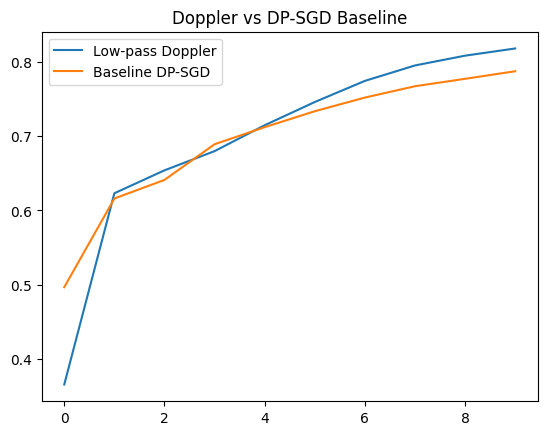

In [9]:
print("=== DOPPLER ===")
model_doppler, hist_doppler = train_mlp_dp_mnist(
    epochs=MAX_EPOCHS,
    sigma=3.0,
    lr=0.1,
    use_doppler=True
)

# Baseline
print("\n=== DP-SGD Baseline ===")
model_base, hist_base = train_mlp_dp_mnist(
    epochs=MAX_EPOCHS,
    sigma=3.0,
    lr=0.1,
    use_doppler=False
)

import matplotlib.pyplot as plt
plt.plot(hist_doppler['accuracy'], label='Low-pass Doppler')
plt.plot(hist_base['accuracy'], label='Baseline DP-SGD')
plt.legend()
plt.title("Doppler vs DP-SGD Baseline")
plt.show()

# Experimentos

- Variar sigma DP
- Verificar se a gente consegue ser melhor em menos épocas
- Testar mais épocas